In [1]:
import numpy as np

from skfem import Basis, ElementVector, ElementComposite, FacetBasis
from skfem.assembly import asm, BilinearForm, LinearForm
from skfem.helpers import grad, sym_grad, div, dot, ddot, trace, eye
from skfem import MeshQuad1, ElementQuad0, ElementQuad1, ElementQuad2, ElementQuadRT0, ElementTriP1, MeshTri
from skfem import ElementLineP2, ElementLineP1, ElementLineP0, MeshLine
from skfem.visuals.matplotlib import draw

import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, lil_matrix
from scipy.integrate import solve_ivp
from scipy.sparse.linalg import splu, spsolve

import ipywidgets as widgets
import time

import autograd.numpy as anp
from autograd import elementwise_grad

## Data

In [2]:
L = 1e-3#.00001 #[m]

ρf = 1000 * L**3
ρs = 2500 * L**3

Kf = 2.2e9 * L**1
Ks = 80e9 * L**1
nu = .15
φ = .2
α = .6

turt = 1 # 1 straight pores, should be larger than 1

k_vv = 1e18*L**3
k_vu = 1e18*L**3
k_r = 1e21*L**3
ηs = 9e-1

k = 1e-18 * L**-2
μf = 1e-3 * L**1

Kb = Ks*(1-α)
G = 3/2*Kb*(1-2*nu)/(1+nu)
M = ((α-φ)/Ks + φ/Kf)**-1
# ρ11 = (1 - φ) * ρs + φ * ρf
# ρ12 = ρf
# ρ22 = ρs / φ + ρf / φ**2


ρ11 = (1 - φ) * ρs + (turt - 1) * φ * ρf
ρ22 = turt * φ * ρf
ρ12 = -(turt - 1) * φ * ρf 
# print(ρ11,ρ22,ρ12)
Δ = ρ11*ρ22 - ρ12**2
mu = G
lam = Kb - 2*G/3
b = (k / μf)**-1

# robin_left = (k_vv*0, 0, k_vu*0, 0, k_r)
robin_left = (k_vv, k_vv, k_vu, k_vu, k_r)
robin_right = (k_vv, 0, k_vu, 0, k_r)

bc_dofs = {
    'u1': {'left': 0.},
    # # 'v1': {'left': 0.},
    'u2': {'left': 0.},
    # # 'v2': {'left': 0.},
    # 'u1': {'left': 0.,'right': 0.},
    # # 'v1': {'left': 0.,'right': 0.},
    # 'p': {'left': 0.,'right': 0.},
}


Dc=.10 /1000/L #mm
Dmu=-.1
mu_res=.5
s11_eff_0 = 4*1e6 * L**1
friction_sides = ["right"]
# friction_sides = []

# Domain
D = 1000. #[m]

Ku = Kb + α**2*M
rho_b = (1-φ)*ρs + φ*ρf
vw = np.sqrt((Ku + 4/3*mu)/rho_b)
print("Δ:",Δ)
print("α:",α)
print("Kb:", Kb*1e-9*L**-1)
print("G:", G*1e-9*L**-1)
print("M/Kb:",M/Kb)
Cm = np.array([[Kb + 4/3*G, α*M],[α*M, M]])
Rm = np.array([[ρ11, ρ12],[ρ12, ρ22]])
tmp = np.linalg.solve(Rm, Cm)  # = Rho^{-1} C
c2, vecs = np.linalg.eig(tmp)
vw1, vw2 = np.sqrt(c2)

print("undrained wave velocity", vw * L**1)
print("wave velocities", vw1 * L**1, vw2 * L**1)
chy = k / μf / M**-1
print("tch_mech:", (D/2)/ vw1 / L, "[s]", (D/2)/ vw2 / L, "[s]")
print("tch_diff:", (D/L/2)**2/chy, "[s]")
print("G/D:", G/(D/L), "dFr/ds", -Dmu*s11_eff_0/Dc )
EQslip = -G/(D /L)> Dmu*s11_eff_0/Dc
print("EQ like slip:", EQslip)
if EQslip:
    expd_slip = -Dmu*s11_eff_0/G*D/L
    print("    Expected seismic slip [m]:",expd_slip*L)

Δ: 4.0000000000000016e-13
α: 0.6
Kb: 32.0
G: 29.21739130434783
M/Kb: 0.32582938388625593
undrained wave velocity 5827.445886863148
wave velocities 5556.573891512603 7532.2937329558945
tch_mech: 0.08998350598085733 [s] 0.06638084197544766 [s]
tch_diff: 23977272727.27273 [s]
G/D: 29.217391304347828 dFr/ds 4000.0
EQ like slip: True
    Expected seismic slip [m]: 0.01369047619047619


In [3]:
point_source_loc = np.array([[.0]])
point_source_Q0 = np.array([[-1e-10*0]])

## Mesh

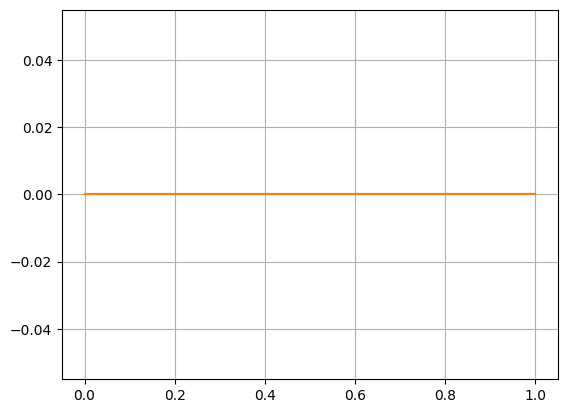

In [4]:
def smoothstep_quintic(x):
    # x assumed in [0,1]
    return x*x*x*(x*(x*6 - 15) + 10)

def smooth_step(t, t0, tau):
    x = (t - t0) / tau
    x = anp.clip(x, 0.0, 1.0)
    return smoothstep_quintic(x)

def smooth_pulse(t, t_start, t_end, tau = 1e-4):
    return (1 - smooth_step(t, t_end, tau)) * smooth_step(t, t_start, tau)
# dq_pulse = agrad(q_pulse, argnum=0)
dsmooth_pulse = elementwise_grad(smooth_pulse, argnum=0)

def qv(t, t_start, t_end, tau=1e-4):
    q0 = point_source_Q0
    return q0[:] * smooth_pulse(t, t_start, t_end, tau)/L**1  # (ns, len(t)) if t is vector

def dqv(t, t_start, t_end, tau=1e-4):
    q0 = point_source_Q0
    return q0[:] * dsmooth_pulse(t, t_start, t_end, tau)/L**1 # (ns, len(t))

tmax = 1.
tau = .1
ts = np.linspace(0, tmax, 1000, endpoint=True)
qs = qv(ts, t_start = 0, t_end = 3*tmax/5, tau = tau)
dqs = dqv(ts, t_start = 0, t_end = 3*tmax/5, tau = tau)
plt.plot(ts,qs.T)
plt.plot(ts,dqs.T)
plt.grid(True)
plt.show()
q = lambda t: qv(t, t_start = 0, t_end = 5*tmax/3, tau = tau).squeeze()
dq = lambda t: dqv(t, t_start = 0, t_end = 5*tmax/3, tau = tau).squeeze()

In [5]:
# Domain setup
xmin, xmax = -D/2, D/2 # [m]

xmin_d, xmax_d = xmin/L, xmax/L

bnd_labels = {
    'left': lambda x: np.isclose(x[0], xmin_d),
    'right': lambda x: np.isclose(x[0], xmax_d),
    }

In [6]:
def meshline_geometric_symmetric(x0, xL, N, q):
    if N % 2 != 0:
        raise ValueError("N must be even for symmetric grading")
    L = xL - x0
    N2 = N // 2

    if abs(q - 1.0) < 1e-14:
        return np.linspace(x0, xL, N + 1)

    h0 = (L/2) * (q - 1.0) / (q**N2 - 1.0)
    h = h0 * q**np.arange(N2)
    x_left = np.concatenate(([0.0], np.cumsum(h)))  # includes 0 and (about) L/2

    # mirror nodes about L/2: exclude the midpoint to avoid duplication
    x_right = L - x_left[-2::-1]  # start from node before midpoint down to 0

    x = x0 + np.concatenate([x_left, x_right])
    x[-1] = xL
    return x

-500000.0 500000.0


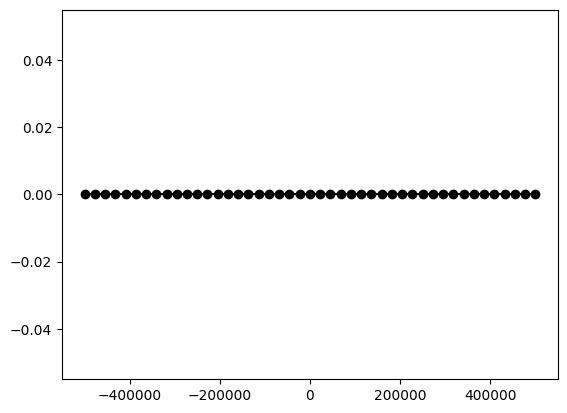

In [7]:
mesh_elements = 43+1
xcoords = np.linspace(xmin_d, xmax_d, mesh_elements + 1)
# xcoords = meshline_geometric_symmetric(xmin_d, xmax_d, mesh_elements, 1.15)
print(np.amin(xcoords),np.amax(xcoords))
mesh = MeshLine(xcoords)

mesh = mesh.with_boundaries(bnd_labels)
left_facets = mesh.boundaries['left']
right_facets = mesh.boundaries['right']

draw(mesh)
plt.show()

## Const. law

In [8]:
def sij_core(E_kl, x_type):
    dim = E_kl.shape[-1]
    if dim == 2:
        batch_shape = E_kl.shape[:-2]
        E_kl_3D = np.zeros(batch_shape + (3, 3), dtype=E_kl.dtype)
        E_kl_3D[..., :dim, :dim] = E_kl
    elif dim == 3:
        E_kl_3D = E_kl
    else:
        raise ValueError("dim must be 1, 2 or 3")
    
    trE = np.trace(E_kl_3D, axis1=-2, axis2=-1)[..., None, None]
    I = np.eye(3, dtype=E_kl_3D.dtype)

    s3 = 2.0 * mu * E_kl_3D + lam * trE * I  # fully broadcasted

    return s3[..., :dim, :dim]   # slice back if dim==2

def Sij(E, x_type):
    """Wrapper that preserves the axis order of E."""
    E = np.asarray(E)
    if E.ndim < 2 or E.shape[0] != E.shape[1] or E.shape[0] not in (2, 3):
        raise ValueError(f"Expected (2,2,...) or (3,3,...), got {E.shape}")

    # move matrix axes (0,1) → (-2,-1), compute, move back
    E_last = np.moveaxis(E, (0, 1), (-2, -1))
    S_last = sij_core(E_last, x_type)
    return np.moveaxis(S_last, (-2, -1), (0, 1))

## FEM

In [9]:
dim = 2
intorder = 4

element_v = ElementLineP2()
element_r = ElementLineP2()
element_u = ElementLineP2()
element_p = ElementLineP1()

# element_v = ElementLineP1()
# element_r = ElementLineP1()
# element_u = ElementLineP1()
# element_p = ElementLineP1()

# element_v = ElementLineP1()
# element_r = ElementLineP1()
# element_u = ElementLineP1()
# element_p = ElementLineP0()

el_v = ElementVector(element_v, dim=dim)
# el_r = element_r
el_r = ElementVector(element_r, dim=dim)
el_u = ElementVector(element_u, dim=dim)
el_p = element_p

mixed_element = ElementComposite(el_v, el_r, el_u, el_p)
basis = Basis(mesh, mixed_element, intorder=intorder)
basis_boundary = FacetBasis(mesh, mixed_element, intorder=intorder)
fbasis_left = FacetBasis(mesh, mixed_element, intorder=intorder, facets=left_facets)
fbasis_right = FacetBasis(mesh, mixed_element, intorder=intorder, facets=right_facets)

@BilinearForm
def varform_lhs(dv, dr, du, dp, δv, δr, δu, δp, w):
    return ρ11 * dot(dv, δv) + ρ22 * dot(dr, δr) + ρ12 * dot(dv, δr) + ρ12 * dot(dr, δv) + dot(du, δu) + dp * δp

def make_sym(gradu):
    o = np.zeros((2, 2, *gradu.shape[2:]), dtype=gradu.dtype)
    o[0, 0] = gradu[0, 0]          # du1/dx
    o[0, 1] = 0.5 * gradu[1, 0]    # 1/2 du2/dx
    o[1, 0] = 0.5 * gradu[1, 0]
    return o

def my_sym_grad(u):
    tt = grad(u)
    return make_sym(tt)
# 
@BilinearForm
def varform_rhs(v, r, u, p, δv, δr, δu, δp, w):
    Eps_kl = my_sym_grad(u)
    Su_ij = Sij(Eps_kl, "quad")
    dEps_kl = my_sym_grad(v)
    Sv_ij = ηs * Sij(dEps_kl, "quad")
    I = np.eye(Eps_kl.shape[0])[:, :, None, None] * np.ones_like(Eps_kl)
    S_ij = Su_ij + Sv_ij - α * I * p
    term_1 = + ddot(S_ij, my_sym_grad(δv)) + b * dot(r, δr) - dot(v, δu)
    term_2 = - dot(p, grad(δr)[0,0]) + M * dot(α * grad(v)[0,0] + grad(r)[0,0], δp)
    return term_1 + term_2

@BilinearForm
def varform_robin(v, r, u, p, δv, δr, δu, δp, w):
    c_vv1, c_vv2, c_vu1, c_vu2, c_r = w.params
    # print(r.shape,w.n.shape)
    rn = r[0] #* w.n #dot(r, w.n)
    δrn = δr[0]# * w.n #dot(δr, w.n)
    term1 = (c_vv1 * v[0] + c_vu1 * u[0]) * δv[0] 
    term1+= (c_vv2 * v[1] + c_vu2 * u[1]) * δv[1] 
    term2 = c_r * rn * δrn
    return term1 + term2

@BilinearForm
def varform_frictional_part(v, r, u, p, δv, δr, δu, δp, w):
    n = w.n
    Eps_kl = my_sym_grad(u)
    Su_ij = Sij(Eps_kl, "quad")
    dEps_kl = my_sym_grad(v)
    Sv_ij = ηs * Sij(dEps_kl, "quad")
    S_ij = Su_ij + Sv_ij - α * I * p
    print(S_ij.shape)
    s11_eff_t = S_ij[0,0]
    t2 = s11_eff_t * n
    return t2 * δv[1]

@BilinearForm
def varform_force(fv, fr, fu, fp, δv, δr, δu, δp, w):
    return + dot(fv + fu, δv) + dot(fr, δr)

E = asm(varform_lhs, basis)
Abulk = - asm(varform_rhs, basis)
Abndr_left = - asm(varform_robin, fbasis_left, params=robin_left)
Abndr_right = - asm(varform_robin, fbasis_right, params=robin_right)
A = Abulk + Abndr_left + Abndr_right

dofs_left  = basis.get_dofs('left').all(["u^1^1", "u^2^1", "u^1^2", "u^2^2"])
Bbndr_force_left = - asm(varform_force, fbasis_left)[:, dofs_left]
dofs_right  = basis.get_dofs('right').all(["u^1^1", "u^2^1", "u^1^2", "u^2^2"])
Bbndr_force_right = - asm(varform_force, fbasis_right)[:, dofs_right]

ndofs = basis.N

In [10]:
@BilinearForm
def varform_t1(v, r, u, p, δv, δr, δu, δp, w):
    n = w.n
    Eps_kl = my_sym_grad(u)
    Su_ij = Sij(Eps_kl, "quad")
    dEps_kl = my_sym_grad(v)
    Sv_ij = ηs * Sij(dEps_kl, "quad")
    S_ij = Su_ij + Sv_ij
    s11_eff_t = S_ij[0,0]
    t1 = s11_eff_t * n
    return t1 * δv[1]
t1_left = asm(varform_t1, fbasis_left)
t1_right = asm(varform_t1, fbasis_right)
print(t1_left.shape)

(579, 579)


In [11]:
def get_atol(atol_fields):
    ids = basis.split_indices()
    atol = np.zeros(basis.N)
    for i, idx in enumerate(ids):
        atol[idx] = atol_fields[i]
    return atol

In [12]:
dx = (np.amax(mesh.p) - np.amin(mesh.p)) / mesh_elements
# sources_RMS_width = .5 * dx
sources_RMS_width = 1.5 * dx
nsrc = len(point_source_loc)
if sources_RMS_width > 0:
    Bp_full = lil_matrix((ndofs, nsrc))
    sigma = sources_RMS_width
    for j, (c) in enumerate(point_source_loc):
        @LinearForm
        def smooth_dirac(δv, δr, δu, δp, w):
            r2 = np.sum((w.x - c[:, None, None])**2, axis = 0)
            g = np.exp(-r2 / 2 / sigma**2)
            # normalize so ∫g dx ≈ 1
            norm_factor = (sigma * np.sqrt(2 * np.pi))**w.x.shape[0]
            return g / norm_factor * δp / dx
        fvec = asm(smooth_dirac, basis)
        @LinearForm
        def avg(δv, δr, δu, δp, w):
            return 1. * δp
        Cp = asm(avg, basis)
        int_g = Cp @ fvec
        print(f"Source {j}: ∫ g ≈ {int_g:.5f} (should be ≈ 1.0)")
        Bp_full[:, j] = fvec.reshape(-1, 1)/L

elif sources_RMS_width == 0:
    Bp_full = lil_matrix((ndofs, nsrc))
    p_ndofs = basis.split_indices()[3]
    basis_p = Basis(mesh, el_p, intorder=intorder)
    for j, xs in enumerate(point_source_loc):
        tmp = basis_p.point_source(xs)
        Bp_full[p_ndofs, j] = tmp
else:
    raise ValueError("Gaussian RMS width cannot be negative.")
B = M * Bp_full.tocsr()


Source 0: ∫ g ≈ 1.00000 (should be ≈ 1.0)


In [13]:
# nsrc = len(point_source_loc)
# Bp_full = lil_matrix((ndofs, nsrc))
# p_ndofs = basis.split_indices()[3]
# basis_p = Basis(mesh, el_p, intorder=intorder)
# for j, xs in enumerate(point_source_loc):
#     tmp = basis_p.point_source(xs)
#     Bp_full[p_ndofs, j] = tmp
# B = M * Bp_full.tocsr()

In [14]:
# help(FacetBasis)

In [15]:
# from scipy.sparse.linalg import eigs
# print(A.shape[0], E.shape[0])
# vals, vecs = eigs(A, k=A.shape[0]-2, which='LR')
# print(np.amin(vals.real))
# print(np.amax(vals.real))
# vals, vecs = eigs(A, k=A.shape[0]-2, which='SR')
# print(np.amin(vals.real))
# print(np.amax(vals.real))
# print(vals.shape)
# # 'LM' : largest magnitude
# # 'SM' : smallest magnitude
# # 'LR' : largest real part
# # 'SR' : smallest real part
# # 'LI' : largest imaginary part
# # 'SI' : smallest imaginary part

In [16]:
user_to_skfem = {
            "v1": "u^1^1",
            "v2": "u^2^1",
            "r1": "u^1^2",
            "r2": "u^2^2",
            "u1": "u^1^3",
            "u2": "u^2^3",
            "p": "u^4",
        }

E_D = E.tolil(); A_D = A.tolil(); B_D = B.tolil()
dofs_D = np.array([],dtype=np.int32)
for field, sides in bc_dofs.items():
    for side, value in sides.items():
        field_skfem = user_to_skfem.get(field)
        dofs_D = np.append(dofs_D, basis.get_dofs(side).all(field_skfem))
E_D[dofs_D,dofs_D] = 1.
A_D[dofs_D,:] = 0.
B_D[dofs_D] = 0.
E_D = E_D.tocsr(); A_D = A_D.tocsr(); B_D = B_D.tocsr()

In [17]:
# print(E_D-E_D.T)

In [18]:
# eigvals = np.linalg.eigvals(np.linalg.inv(E.toarray())@A.toarray())
# eigvals = np.linalg.eigvals(np.linalg.inv(E_D.toarray())@A_D.toarray())
# eigvals = np.linalg.eigvals(E.toarray())
# eigvals = np.linalg.eigvals(E_D.toarray())
eigvals = np.linalg.eigvals(A_D.toarray())
# eigvals = np.linalg.eigvals(A.toarray())
mineig=np.amin(eigvals.real)
maxeig=np.amax(eigvals.real)
print(mineig)
print(maxeig)
# vecs_sorted = vecs[:, idx]
# idx = np.argsort(-eigvals.real)
# vals_sorted = eigvals[idx]
# print(vals_sorted)

-1003033191920.2743
0.0


In [19]:
sides = ["left", "right"]
TPloc = {"left": 0, "right": 0}
for side in sides:
    t1_node = basis.get_dofs(side).all(user_to_skfem["v1"])[0]
    t2_node = basis.get_dofs(side).all(user_to_skfem["v2"])[0]
    v2_node = t2_node
    u2_node = basis.get_dofs(side).all(user_to_skfem["u2"])[0]
    p_node  = basis.get_dofs(side).all(user_to_skfem["p"])[0]
    T1 = np.zeros(ndofs,dtype = np.int32); T1[t1_node] = 1
    T2 = np.zeros(ndofs,dtype = np.int32); T2[t2_node] = 1
    Pv2 = np.zeros(ndofs,dtype = np.int32); Pv2[v2_node] = 1
    Pu2 = np.zeros(ndofs,dtype = np.int32); Pu2[u2_node] = 1
    Pp = np.zeros(ndofs,dtype = np.int32); Pp[p_node] = 1
    TPloc[side]=[T1, T2, Pv2, Pu2, Pp]

def set_friction(rhs, z, sides = []):
    if len(sides) == 0: return rhs
    for side in sides:
        T1, T2, Pv2, Pu2, Pp = TPloc[side]
        u_slip = Pu2 @ z
        v_slip = Pv2 @ z
        t1_tilde = T1 @ rhs
        p = Pp @ z#rhs
        t1_eff_tilde = (t1_tilde + α * p)
        t1_eff_bar = s11_eff_0
        if side == "left": t1_eff_bar*=-1.
        t2_tilde = mu_fric(u_slip, v_slip) * (t1_eff_bar + t1_eff_tilde) - mu_fric(0, 0) * t1_eff_bar
        # print(p,t1_eff_bar + t1_eff_tilde)
        sgn = -mysign(v_slip)
        t2_tilde*= sgn
        rhs[t2_node]+= t2_tilde
    return rhs

In [20]:
E_lu = splu(E.tocsc())   # one-time factorization

def rhs_plant(t, z):
    rhs = A_D @ z + B_D @ dq(t)
    rhs+= Bbndr_force_left @ force_left(t)
    rhs+= Bbndr_force_right @ force_right(t)
    rhs = set_friction(rhs, z, friction_sides)
    
    rhs = E_lu.solve(rhs)
    rhs[dofs_D] = 0.
    return rhs

def rhs(t, z):
    rhs = rhs_plant(t,z)
    return rhs

def with_progress(fun, t0, tf, step_percent=1):
    last = {"p": -1}

    def wrapped(t, y):
        p = int(100 * (t - t0) / (tf - t0))
        if p >= last["p"] + step_percent:
            last["p"] = p
            print(f"\rProgress: {p:3d}%", end="", flush=True)
        return fun(t, y)

    return wrapped

# (optional, helps stiff solvers)
def jac(t, z):
    return E_lu.solve(A.toarray() if hasattr(A, "toarray") else A)

## Plotting

In [21]:
def split_sol(zs):
    (v, vb), (r, rb), (u, ub), (p, pb) = basis.split(zs)
    v = [vi[vib.nodal_dofs[0]] for vi, vib in vb.split(v)]
    r = [ri[rib.nodal_dofs[0]] for ri, rib in rb.split(r)]
    u = [ui[uib.nodal_dofs[0]] for ui, uib in rb.split(u)]
    if len(pb.nodal_dofs) == 0:
        p_ext = np.pad(p, ((1, 1), (0, 0)), mode="edge")
        p = 0.5 * (p_ext[1:, :] + p_ext[:-1, :])
    else:
        p = p[pb.nodal_dofs].squeeze()
    return np.array([*v[:dim], *r[:dim], *u[:dim], p])

# m_tri = MeshTri().init_tensor(np.linspace(xmin, xmax, mesh_elements + 1), np.linspace(ymin, ymax, mesh_elements + 1))

def plot_solution(z, v_min, v_max):
    v1, v2, r1, r2, u1, u2, p = z
    fig, ax = plt.subplots(2, 2, figsize=(8, 4))
    # Plot v1, v2
    i = 0; j = 0
    tcf = ax[i, j].plot(xcoords * L, v1, "b", label = "$v_1$")
    tcf = ax[i, j].plot(xcoords * L, v2, "r", label = "$v_2$")
    ax[i, j].legend()
    if min(v_min[0],v_min[1]) != max(v_max[0],v_max[1]):
        ax[i, j].set_ylim(min(v_min[0],v_min[1]),max(v_max[0],v_max[1]))
    ax[i, j].set_xlabel("$x$")
    
    # Plot u1, u2
    i = 0; j = 1
    tcf = ax[i, j].plot(xcoords * L, u1, "b", label = "$u_1$")
    tcf = ax[i, j].plot(xcoords * L, u2, "r", label = "$u_2$")
    ax[i, j].legend()
    if min(v_min[4],v_min[5]) != max(v_max[4],v_max[5]):
        ax[i, j].set_ylim(min(v_min[4],v_min[5]),max(v_max[4],v_max[5]))
    ax[i, j].set_xlabel("$x$")
    
    # Plot r1, r2
    i = 1; j = 0
    tcf = ax[i, j].plot(xcoords * L, r1, "b", label = "$r_1$")
    tcf = ax[i, j].plot(xcoords * L, r2, "r", label = "$r_2$")
    ax[i, j].legend()
    if min(v_min[2],v_min[3]) != max(v_max[2],v_max[3]):
        ax[i, j].set_ylim(min(v_min[2],v_min[3]),max(v_max[2],v_max[3]))
    ax[i, j].set_xlabel("$x$")

    # Plot p
    i = 1; j = 1
    tcf = ax[i, j].plot(xcoords * L, p, "b", label = "$p$")
    ax[i, j].legend()
    if v_min[6] != v_max[6]:
        ax[i, j].set_ylim(v_min[6], v_max[6])
    ax[i, j].set_xlabel("$x$")
    
    plt.tight_layout()

def plot_tensor(tensor, v_min_t, v_max_t, name="tensor"):
    n, m, _ = tensor.shape
    fig, ax = plt.subplots(n, m, figsize=(8, 4))
    for i in range(n):
        for j in range(m):
            tcf = ax[i, j].plot(xcoords * L, tensor[i,j])
            ax[i, j].set_title(f"${name}_{{{i+1}{j+1}}}$")
            if v_min_t[i,j] != v_max_t[i,j]:
                ax[i, j].set_ylim(v_min_t[i,j], v_max_t[i,j])
            # ax[i, j].set_aspect('equal')
    plt.tight_layout()

def plot_point_hist(ss, ss_eff, zs_split, pids):
    fig, ax = plt.subplots(len(pids), 3, figsize=(10, 6))
    for i, pid in enumerate(pids):
        xpid = np.round(xcoords[pid] * L,1)
        ax[i, 0].plot(ts, ss[:,0,0,pid],label="$\\sigma_{11}$ @ x="+str(xpid))
        ax[i, 0].plot(ts, zs_split[:,6,pid],label="$p$ @ x="+str(xpid))
        ax[i, 0].plot(ts, ss_eff[:,0,0,pid],label="$\\sigma'_{11}$ @ x="+str(xpid))
        ax[i, 0].legend()
        ax[i, 0].grid(True)
        ax[i, 0].set_xlabel("$t$")
        ax[i, 1].plot(ts, ss[:,0,1,pid],label="$\\sigma_{12}$ @ x="+str(xpid))
        ax[i, 1].plot(ts, ss_eff[:,0,1,pid],label="$\\sigma'_{12}$ @ x="+str(xpid))
        ax[i, 1].legend()
        ax[i, 1].grid(True)
        ax[i, 1].set_xlabel("$t$")
        μmob = np.divide(ss[:,0,1,pid], ss_eff[:,0,0,pid],
                       out=np.zeros_like(ss[:,0,1,pid]),
                       where=ss_eff[:,0,0,pid] != 0)
        # print(np.amax(μmob))
        ax[i, 2].plot(ts, μmob,label="$\\mu_{mob}$ @ x="+str(xpid))
        ax[i, 2].legend()
        ax[i, 2].grid(True)
        ax[i, 2].set_xlabel("$t$")
    plt.tight_layout()


In [22]:
def get_grad_QM(ubasis_scalar):
        """
        Computes the weak gradient and mass matrices.
        """
        @BilinearForm
        def ds_dxi(s, δs, w):
            return grad(s)[w['i']] * δs

        @BilinearForm
        def mass(s, δs, w):
            return s * δs
    
        Q = [ds_dxi.assemble(ubasis_scalar, i=i)  for i in range(1)]
        M = mass.assemble(ubasis_scalar)
        M_lu = splu(M.tocsc())
        return Q, M, M_lu

(_, _), (_, _), (u, ub), (_, _) = basis.split(np.zeros(ndofs))
ubasis_scalar = ub.split_bases()[0]
gradu_QM = get_grad_QM(ubasis_scalar)

def get_gradu(u_components):
        """
        Computes the weak gradients at mesh nodes.
        u_components: list/array of length dim, each element shape (ndofs,)
        Returns: gradu with shape (dim, dim, ndofs)
                gradu[i, j, :] = ∂u_i/∂x_j (weak gradient)
        """
        Q, _, M_lu = gradu_QM

        # Stack components into one 2D array: (dim, ndofs)
        U = np.stack(u_components, axis=0)          # (dim, ndofs)

        grads_per_j = []
        for j in range(1):
            # Q[j] @ U.T: (ndofs, dim) — all components at once
            rhs = Q[j] @ U.T                         # (ndofs, dim)
            sol = M_lu.solve(rhs)                    # (ndofs, dim)
            grads_per_j.append(sol.T)                # (dim, ndofs)

        # grads_per_j: list of length dim, each (dim, ndofs)
        # gradu: (dim, dim, ndofs)
        gradu = np.stack(grads_per_j, axis=1)
        return gradu

def compute_stress_strain(zs, only_nodal = True):
    ss = []; es = [];
    for t_ind, z in enumerate(zs.T):
        (v, vb), (_, _), (u, ub), (p, pb) = basis.split(z)            
        components = ub.split(u)
        u_components = [comp[0] for comp in components]   # [u_x, u_y, (u_z)]
        gradu = get_gradu(u_components)
        
        components = ub.split(v)
        v_components = [comp[0] for comp in components]   # [u_x, u_y, (u_z)]
        gradv = get_gradu(v_components)
        
        x_type = "node_all"
        if only_nodal:
            gradu = gradu[:, :, ubasis_scalar.nodal_dofs[0]]
            gradv = gradv[:, :, ubasis_scalar.nodal_dofs[0]]
            x_type = "node"
        
        e = make_sym(gradu)
        de = make_sym(gradv)
        s = Sij(e, x_type) + ηs * Sij(de, x_type)
        
        ss.append(s)
        es.append(e)
    return np.array(ss), np.array(es)

## Steady state

In [23]:
# rhs_ss = -B @ np.ones(len(point_source_loc))
# z_ss = spsolve(A, rhs_ss)[:, None]
# z_ss_split = split_sol(z_ss)
# vmin=np.amin(z_ss_split, axis=1).squeeze()*1.1
# vmax=np.amax(z_ss_split, axis=1).squeeze()*1.1
# equal = np.abs(vmin - vmax)<=1e-2
# vmin[equal & (vmin < 0)] = 0.
# vmax[equal & (vmin >= 0)] = 0.
# plot_solution(z_ss_split, vmin, vmax)

## Eigen analysis

In [24]:
A_tilde = A_D.toarray()#np.linalg.solve(E_D.toarray(), A_D.toarray())
eigvals, eigvectors = np.linalg.eig(A_tilde)
idx = np.argsort(np.abs(eigvals.real))
eigvcs = eigvectors[:,idx]
# print(eigvals[idx[0]])
# print(eigvcs[:,idx[0]])
eigvcs_split = split_sol(eigvcs).transpose(2, 0, 1)
vmin=-np.ones(7)/5#np.amin(eigvcs_split, axis=(0,2))*1.1
vmax=-vmin #np.amax(eigvcs_split, axis=(0,2))*1.1
# print(eigvcs_split[ivc,:,:])

@widgets.interact(tid=(0,eigvals.shape[0]-1,1))
def show_animate(tid=0):
    plot_solution(eigvcs_split[tid], vmin, vmax)
    print("@ eigv=",eigvals[idx[tid]])
    # print(np.linalg.norm(eigvcs_split[tid].flatten()))
    print(np.linalg.norm(eigvcs[:,tid]))

interactive(children=(IntSlider(value=0, description='tid', max=578), Output()), _dom_classes=('widget-interac…

In [25]:
# print(1/0)

## Integration

In [26]:
def mu_fric(slip, slip_rate):
    a=mu_res*(1. -Dmu/mu_res*np.exp(-slip/Dc))
    return a
    
def mysign(x, epsilon=1e-9):
    # a = np.tanh(x / epsilon)
    a = x/np.sqrt(x**2 + epsilon/L)
    return a*0+1

# Initial condition
def IC(xn):
    x = xn[0] * L
    v = 1.e-6 * (x + D / 2) / D
    return v / L

y0 = np.zeros(ndofs)
(vi, vb), (ri, rb), (ui, ub), (pi, pb) = basis.split(y0)
(v1i, vb1), (v2i, vb2) = vb.split(y0)
idx2 = vb.split_indices()[1]
v20 = vb1.project(IC)
vi[idx2]=v20
idx = basis.split_indices()[0]
y0[idx] = vi

smoother tau 0.015600160460353294


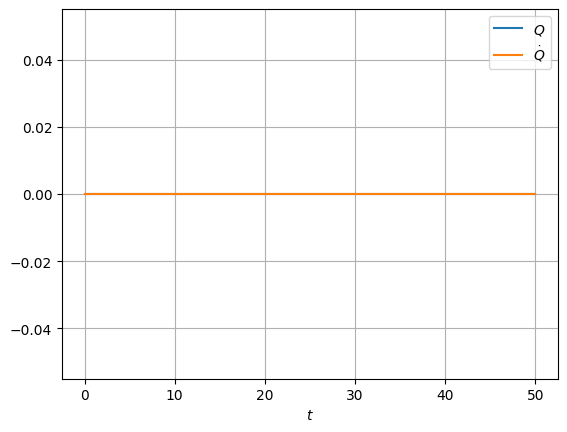

Progress: 100%
elapsed time: 5.8 sec
True


In [27]:
tmax = 50.#*312500000000.0#5.
t_span = (0, tmax)
# t_eval = np.linspace(0, tmax, 31, endpoint=True)
t_eval = np.arange(0, tmax, D/L/vw/100)
# t_eval = np.append(t_eval, tmax)

rhs_prog = with_progress(rhs, 0, tmax)

dx = (np.amax(mesh.p) - np.amin(mesh.p)) / mesh_elements
dt_crit = dx / vw
tau = 4 * dt_crit
print("smoother tau", tau)
q = lambda t: qv(t, t_start = 0.0, t_end = tmax, tau = tau).reshape(-1)
dq = lambda t: dqv(t, t_start = 0.0, t_end = tmax, tau = tau).reshape(-1)
# print(q(.2).squeeze())

smooth_amp = lambda t: smooth_pulse(t, t_start = 0, t_end = tmax, tau = tau)
force_left = lambda t: np.array([0,0,0,0]) * smooth_amp(t) * L**1
force_right = lambda t: np.array([0,0*1e3,0,0]) * smooth_amp(t) * L**1

ts = np.linspace(0, tmax, 1000, endpoint=True)
plt.plot(ts,q(ts).T, label = "$Q$")
plt.plot(ts,dq(ts).T, label = "$\\dot Q$")
plt.legend()
plt.xlabel("$t$")
plt.grid(True)
plt.show()

atol_fields = np.array([1e-9,1e-12,1e-9,1e-10])
atol = get_atol(atol_fields)
rtol = 1e-8

start = time.time()
sol = solve_ivp(fun=rhs_prog, t_span=t_span, y0=y0, method='Radau', atol=atol, rtol=rtol, t_eval=t_eval)#, jac=jacobian)#, max_step=1.1*np.min(np.diff(t_eval)))
# sol = solve_ivp(fun=rhs_prog, t_span=t_span, first_step = dt_crit/10,max_step = tmax/10, y0=y0, method='Radau', atol=atol, rtol=rtol, t_eval=t_eval)#, jac=jacobian)#, max_step=1.1*np.min(np.diff(t_eval)))
end = time.time(); time_sol = end - start
print("\nelapsed time:", round(time_sol if time_sol < 60 else time_sol / 60, 2), 'sec' if time_sol < 60 else 'min')
print(sol.success)
ts = sol.t; zs = sol.y

In [28]:
zs_split = split_sol(zs).transpose(2, 0, 1)
print(zs.shape)
print(zs_split.shape)
zs_split[:,:6,:]*=L
zs_split[:,6,:]/=L
# print( zs_split.argmax(axis=(1,2)))
vmin=np.amin(zs_split, axis=(0,2))*1.1
vmax=np.amax(zs_split, axis=(0,2))*1.1
# print(vmin)
# print(vmax)
# print(zs_split.shape)
ss_eff, es = compute_stress_strain(zs)
ss_eff/= L
I = np.eye(dim)
ss = ss_eff - α * zs_split[:, 6, None, None, :] * I[None, :, :, None]
vmin_ss_eff=np.amin(ss_eff, axis=(0,3))*1.1
vmax_ss_eff=np.amax(ss_eff, axis=(0,3))*1.1
vmin_ss=np.amin(ss, axis=(0,3))*1.1
vmax_ss=np.amax(ss, axis=(0,3))*1.1
vmin_es=np.amin(es, axis=(0,3))*1.1
vmax_es=np.amax(es, axis=(0,3))*1.1

(579, 29138)
(29138, 7, 45)


## Results

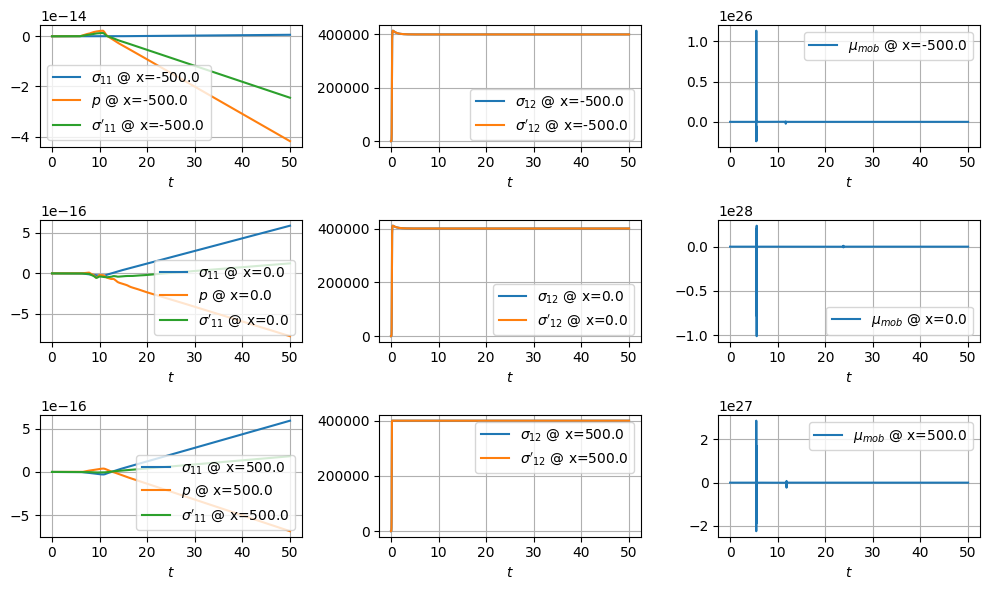

In [29]:
pids=[0, mesh_elements//2, -1]
plot_point_hist(ss, ss_eff, zs_split, pids)

In [30]:
@widgets.interact(tid=(0,len(ts)-1,1))
def show_animate(tid=len(ts)):
    plot_solution(zs_split[tid], vmin, vmax)
    print("@ t=",ts[tid])

interactive(children=(IntSlider(value=29137, description='tid', max=29137), Output()), _dom_classes=('widget-i…

In [31]:
@widgets.interact(tid=(0,len(ts)-1,1))
def show_animate(tid=len(ts)):
    plot_tensor(ss_eff[tid], vmin_ss_eff, vmax_ss_eff, name="\\sigma'")
    plot_tensor(ss[tid], vmin_ss, vmax_ss, name="\\sigma")
    plt.show()

interactive(children=(IntSlider(value=29137, description='tid', max=29137), Output()), _dom_classes=('widget-i…

In [32]:
@widgets.interact(tid=(0,len(ts)-1,1))
def show_animate(tid=len(ts)):
    plot_tensor(es[tid], vmin_es, vmax_es, name="\\epsilon")

interactive(children=(IntSlider(value=29137, description='tid', max=29137), Output()), _dom_classes=('widget-i…

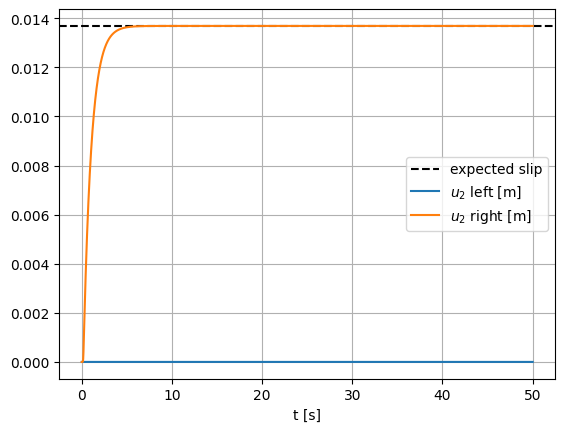

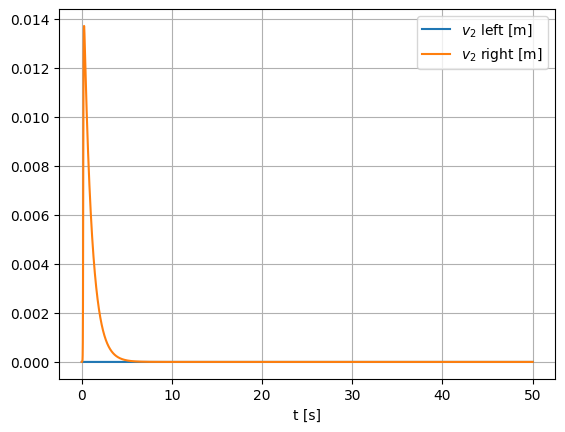

In [33]:
tst=0
dof_id = 5
plt.axhline(expd_slip*L, color='black', linestyle='--',label="expected slip")
plt.plot(ts[tst:],zs_split[tst:,dof_id,0],label="$u_2$ left [m]")
plt.plot(ts[tst:],zs_split[tst:,dof_id,-1],label="$u_2$ right [m]")
plt.grid(True)
plt.xlabel("t [s]")
plt.legend()
plt.show()
dof_id = 1
plt.plot(ts[tst:],zs_split[tst:,dof_id,0],label="$v_2$ left [m]")
plt.plot(ts[tst:],zs_split[tst:,dof_id,-1],label="$v_2$ right [m]")
plt.grid(True)
plt.xlabel("t [s]")
plt.legend()
plt.show()

In [34]:
# ss=np.linspace(0,1/L,100)
# # print(mu_fric(0,0))
# test= mu_fric(ss,ss*0)
# # print(test)
# plt.plot(ss,test)

# mu_fric(100000000, 100000000) * (s11_eff_0 ) - mu_fric(0, 0) * s11_eff_0
print(1/0)

ZeroDivisionError: division by zero

## Control

In [ ]:
import control as ct
import scipy.linalg as la

: 

In [ ]:
xball_max = np.amax(mesh.p)
xball_min = xball_max - dx

: 

### C Matrix

In [ ]:
# smooth version
def ball(x):
    return ((x >= xball_min) & (x <= xball_max)).astype(float)
@LinearForm
def ball_avg(δv, δr, δu, δp, w):
    # print(δv.shape)
    # print(ball(w.x).shape)
    return ball(w.x)[0] * δv[1] / dx
Cc = asm(ball_avg, basis)
# print(Cc.shape)
# print(Cc)

# point version
u_node = basis.get_dofs("right").all(user_to_skfem["v2"])[0]
Cc = np.zeros(ndofs)
Cc[u_node] = 1.
# print(Cc.shape)
# print(Cc)

: 

### A Matrix

In [ ]:
sc = max(np.abs(mineig),np.abs(maxeig))
print(sc)
# sc = 1.

13183.416759310488


: 

In [ ]:
Ac = A_D.toarray()/sc
Ec = E_D.toarray()/sc

: 

### B Matrix

In [ ]:
Bc = B_D.toarray()/sc

: 

### D Matrix

In [ ]:
Dc = np.zeros((Cc.shape[0], Bc.shape[1]))

: 

### System

In [ ]:
# sys = ct.ss(Ac, Bc, Cc, Dc, name="plant")
# print(sys)


: 

In [ ]:
# sc = max(np.abs(mineig),np.abs(maxeig))
# print(sc)
# # # ct.ctrb(Ac/sc, Bc/sc)
# # ct.obsv(Ac/sc, Cc/sc)

: 

In [ ]:
eigs = la.eigvals(Ac)
print("max |eig(A)|:", np.max(np.abs(eigs)))
print("max Re(eig(A)):", np.max(np.real(eigs)))

max |eig(A)|: 1.0000000000000004
max Re(eig(A)): 0.0


: 

In [ ]:
import numpy as np
import scipy.linalg as la

import numpy as np
import scipy.linalg as la

def pbh_stabilizable_rel(A, B, continuous=True, rtol=1e3):
    """
    Relative PBH stabilizability test.

    Returns
    -------
    ok : bool
        True if the system appears stabilizable.
    worst_ratio : float
        Minimum smin/smax over checked unstable/marginal modes.
    failing : list
        List of tuples (lam, smin, smax, ratio) for modes that fail.
    checked : list
        Same tuple for all checked modes.

    Criterion
    ---------
    For each relevant eigenvalue lam of A:
        rank([lam I - A, B]) == n

    Numerically, declare failure if
        smin/smax <= rtol * eps
    where eps is machine epsilon for float64.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    if A.ndim != 2 or A.shape[0] != A.shape[1]:
        raise ValueError("A must be a square 2D array.")

    n = A.shape[0]

    if B.ndim == 1:
        B = B.reshape(-1, 1)
    elif B.ndim != 2:
        raise ValueError("B must be a 1D or 2D array.")

    if B.shape[0] != n:
        raise ValueError("B must have the same number of rows as A.")

    I = np.eye(n, dtype=A.dtype)
    eigs = la.eigvals(A)

    if continuous:
        to_check = [lam for lam in eigs if np.real(lam) >= 0]
    else:
        to_check = [lam for lam in eigs if np.abs(lam) >= 1]

    if not to_check:
        return True, np.inf, [], []

    eps = np.finfo(float).eps
    thresh = rtol * eps

    failing = []
    checked = []
    worst_ratio = np.inf

    for lam in to_check:
        M = np.hstack((lam * I - A, B))
        s = la.svdvals(M)
        smin, smax = s[-1], s[0]
        ratio = smin / smax if smax > 0 else 0.0

        record = (lam, smin, smax, ratio)
        checked.append(record)
        worst_ratio = min(worst_ratio, ratio)

        if ratio <= thresh:
            failing.append(record)

    return len(failing) == 0, worst_ratio, failing, checked

: 

In [ ]:
ok, worst_ratio, failing, checked = pbh_stabilizable_rel(Ac, Bc, continuous=True, rtol=1e3)
print("stabilizable:", ok)
print("failing:", failing)
print("worst ratio:", worst_ratio)
print("example checked:", checked[0])

: 

In [ ]:
def diag_balance(A, B):
    # simple balancing (similarity transform) to reduce scaling issues
    Abal, T = la.matrix_balance(A, permute=False, scale=True)
    # For similarity transform x = T z  =>  z_dot = T^{-1} A T z + T^{-1} B u
    Binv = la.solve(T, B)
    return Abal, Binv, T

Abal, Bbal, T = diag_balance(Ac, Bc)
ok2, worst_ratio2, failing2, checked2 = pbh_stabilizable_rel(Abal, Bbal, continuous=True, rtol=1e3)
print("stabilizable:", ok2)
print("worst ratio:", worst_ratio2)
print("example checked:", checked2[0])

: 

In [ ]:
import numpy as np
import scipy.linalg as la

def pbh_detectable_rel(A, C, continuous=True, rtol=1e3, unstable_tol=0.0):
    """
    Relative PBH detectability test using SVD of [λI - A; C].

    Detectable iff rank([λI - A; C]) = n for all unstable/marginal eigenvalues λ of A.

    Parameters
    ----------
    A, C : array_like
        State and output matrices.
    continuous : bool
        True: check modes with Re(λ) >= -unstable_tol
        False: check modes with |λ| >= 1 - unstable_tol
    rtol : float
        Multiplier on machine epsilon for declaring numerical rank deficiency
        via ratio = smin/smax <= rtol*eps.
    unstable_tol : float
        Small margin for classifying “unstable” (helps with near-marginal modes).

    Returns
    -------
    detectable : bool
    worst_ratio : float
        Minimum over checked modes of (smin/smax).
    failing : list
        List of tuples (λ, smin, smax, ratio) that fail.
    checked : list
        Same tuples for all checked λ.
    """
    A = np.atleast_2d(np.asarray(A, dtype=complex))
    C = np.atleast_2d(np.asarray(C, dtype=complex))
    n = A.shape[0]
    I = np.eye(n, dtype=complex)

    eigs = la.eigvals(A)

    if continuous:
        to_check = [lam for lam in eigs if np.real(lam) >= -unstable_tol]
    else:
        to_check = [lam for lam in eigs if np.abs(lam) >= 1 - unstable_tol]

    if len(to_check) == 0:
        return True, np.inf, [], []

    eps = np.finfo(float).eps
    failing, checked = [], []
    worst_ratio = np.inf

    for lam in to_check:
        M = np.vstack((lam * I - A, C))
        s = la.svdvals(M)
        smin, smax = s[-1].real, s[0].real
        ratio = (smin / smax) if smax != 0 else 0.0
        tup = (lam, smin, smax, ratio)
        checked.append(tup)
        worst_ratio = min(worst_ratio, ratio)
        if ratio <= rtol * eps:
            failing.append(tup)

    return (len(failing) == 0), worst_ratio, failing, checked

: 

In [ ]:
ok, worst, failing, checked = pbh_detectable_rel(Ac, Cc, continuous=True)
print("detectable:", ok)
print("failing lambdas:", [f[0] for f in failing])

: 

In [ ]:
import numpy as np
import scipy.linalg as la

import numpy as np
import scipy.linalg as la

def pbh_stabilizable_descriptor_rel(
    E, A, B, continuous=True, rtol=1e3, unstable_tol=0.0,
    check_infinite=False
):
    """
    Relative PBH stabilizability test for descriptor systems
        E xdot = A x + B u

    Assumes the pencil A - lambda E is regular if the result is to be
    interpreted in the standard descriptor-system sense.

    Checks, for each finite unstable generalized eigenvalue lambda of (A, E),
        rank([lambda E - A, B]) = n

    If check_infinite=True, also reports the relative rank test on [E, B],
    but this should be interpreted cautiously: it is not a universal PBH
    stabilizability criterion for infinite eigenstructure.
    """
    E = np.asarray(E, dtype=complex)
    A = np.asarray(A, dtype=complex)
    B = np.asarray(B, dtype=complex)

    S, T, Q, Z = la.qz(A, E, output='complex')
    alpha = np.diag(S)
    beta = np.diag(T)
    
    scale = max(la.norm(A, 2), la.norm(E, 2), 1.0)
    thresh = rtol * np.finfo(float).eps * scale
    
    if np.any((np.abs(alpha) <= thresh) & (np.abs(beta) <= thresh)):
        print(    "Aborted: the pencil A - lambda E appears numerically singular "
            "(irregular), so the PBH descriptor test is not reliable.")
        return None, None, [], [], False, (
            "Aborted: the pencil A - lambda E appears numerically singular "
            "(irregular), so the PBH descriptor test is not reliable."
        )

    if E.ndim != 2 or A.ndim != 2 or E.shape != A.shape or A.shape[0] != A.shape[1]:
        raise ValueError("E and A must be square matrices of the same shape.")

    n = A.shape[0]

    if B.ndim == 1:
        B = B.reshape(-1, 1)
    elif B.ndim != 2:
        raise ValueError("B must be 1D or 2D.")
    if B.shape[0] != n:
        raise ValueError("B must have n rows.")

    eigs = la.eigvals(A, E)
    finite = [lam for lam in eigs if np.isfinite(lam)]

    if continuous:
        to_check = [lam for lam in finite if np.real(lam) >= -unstable_tol]
    else:
        to_check = [lam for lam in finite if np.abs(lam) >= 1 - unstable_tol]

    eps = np.finfo(float).eps
    thresh = rtol * eps

    failing = []
    checked = []
    worst_ratio = np.inf

    for lam in to_check:
        M = np.hstack((lam * E - A, B))
        s = la.svdvals(M)
        smin, smax = s[-1], s[0]
        ratio = smin / smax if smax > 0 else 0.0
        rec = (lam, smin, smax, ratio)
        checked.append(rec)
        worst_ratio = min(worst_ratio, ratio)
        if ratio <= thresh:
            failing.append(rec)

    inf_check_ok = None
    ratio_inf = None
    if check_infinite:
        Minf = np.hstack((E, B))
        s_inf = la.svdvals(Minf)
        ratio_inf = s_inf[-1] / s_inf[0] if s_inf[0] > 0 else 0.0
        inf_check_ok = ratio_inf > thresh

    ok = (len(failing) == 0)
    return ok, worst_ratio, failing, checked, inf_check_ok, ratio_inf

: 

In [ ]:
ok, worst_ratio, failing, checked, inf_check_ok, ratio_inf = pbh_stabilizable_descriptor_rel(Ec, Ac, Bc, continuous=True)

print("stabilizable:", ok)
print("infinity condition ok:", inf_check_ok)
print("worst_ratio:", worst_ratio)
print("failing modes:", [f[0] for f in failing])

Aborted: the pencil A - lambda E appears numerically singular (irregular), so the PBH descriptor test is not reliable.
stabilizable: None
infinity condition ok: False
worst_ratio: None
failing modes: []


: 

In [ ]:
ok, worst_ratio, failing, checked, inf_ok = pbh_detectable_descriptor_rel(Ec, Ac, Cc, continuous=True)

print("stabilizable:", ok)
print("infinity condition ok:", inf_ok)
print("worst_ratio:", worst_ratio)
print("failing modes:", [f[0] for f in failing])

: 

## Draft

In [ ]:
# symmetry check
tst=basis.split_indices()
print(tst[0].shape)
AA = A#.todense()
idx1=tst[1]
idx2=tst[3]
A12 = AA[np.ix_(idx1, idx2)]
A21 = AA[np.ix_(idx2, idx1)]
print(AA.shape)
A12 = A12.todense()
A21 = A21.todense()
sym_err = np.linalg.norm(A12 - A21.T, ord='fro')
f=(np.linalg.norm(A12, ord='fro')+np.linalg.norm(A21, ord='fro')) /2
if f!=0:
    sym_err = np.linalg.norm(A12 - A21.T, ord='fro') / f
print("relative symmetry error:", sym_err)

# definiteness check via random Rayleigh quotients
for _ in range(10):
    x = np.random.randn(AA.shape[0])
    Ax = AA @ x            # gives (1, 605) in your case
    Ax = np.asarray(Ax).ravel()   # -> (605,)

    rq = float(x @ Ax) / float(x @ x)
    print(rq)

: 

In [ ]:
tst=0
plt.plot(ts[tst:],zs_split[tst:,6,0])
plt.plot(ts[tst:],zs_split[tst:,6,-1])
plt.show()

: 

In [ ]:
ppsL = zs_split[:,6,0]
sefL = ss_eff[:,0,0,0]
# print(ss_eff.shape)
ppsR = zs_split[:,6,-1]
sefR = ss_eff[:,0,0,-1]
stotL = sefL - α * ppsL
stotR = sefR - α * ppsR
eeL = es[:,0,0,0]
eeR = es[:,0,0,-1]
plt.plot(ts,stotL)
plt.plot(ts,stotR)
# plt.plot(ts,ppsL)
# plt.plot(ts,ppsR)
# plt.plot(ts,sefL)
# plt.plot(ts,sefR)
# plt.plot(ts,eeL)
# plt.plot(ts,eeR)
plt.grid(True)
plt.show()

: 